In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
file_path = ('/content/drive/MyDrive/DataScience Projects/Zomato data.csv')
data=pd.read_csv(file_path ,lineterminator='\n', on_bad_lines='skip')
df=pd.DataFrame(data)
display(df.head())
display(df.tail())


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining
147,Vijayalakshmi,Yes,No,3.9/5,47,200,Dining


Checking te Dataset

In [29]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


,0
0,False
1,False
2,False
3,False
4,False
...,...
143,False
144,False
145,False
146,False


# Extracting the information from Dataset


In [30]:
# What type of restaurant do the majority of customers order from?

costumer_order=df["listed_in(type)"].value_counts().reset_index()
costumer_order.columns = ['costumer_order', 'Total Orders/Listings']
print("Answer 1: Majority of customers order from:")
display(costumer_order.style.hide(axis="index"))




Answer 1: Majority of customers order from:


costumer_order,Total Orders/Listings
Dining,110
Cafes,23
other,8
Buffet,7


/tmp/ipykernel_22526/2456815931.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=costumer_order,x="costumer_order",y="Total Orders/Listings",palette="bright")


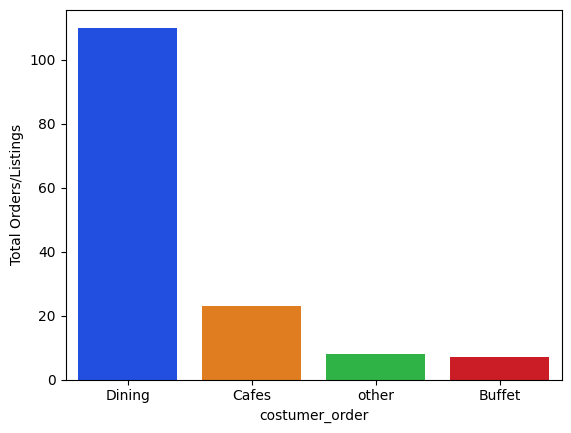

In [31]:
sns.barplot(data=costumer_order,x="costumer_order",y="Total Orders/Listings",palette="bright")
plt.show()

In [32]:
# How many votes has each type of restaurant received from customers?
vote=df.groupby("listed_in(type)")["votes"].sum().reset_index()
vote.columns=["Resturant_Type","Total_Votes"]
vote= vote.sort_values(by='Total_Votes', ascending=False)
print("Answer 2: Total votes by restaurant type:")
display(vote.style.hide(axis='index'))

Answer 2: Total votes by restaurant type:


Resturant_Type,Total_Votes
Dining,20363
other,9367
Cafes,6434
Buffet,3028


/tmp/ipykernel_22526/2567417773.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Resturant_Type", y="Total_Votes", data=vote, palette="viridis")


Text(0, 0.5, 'Total Votes')

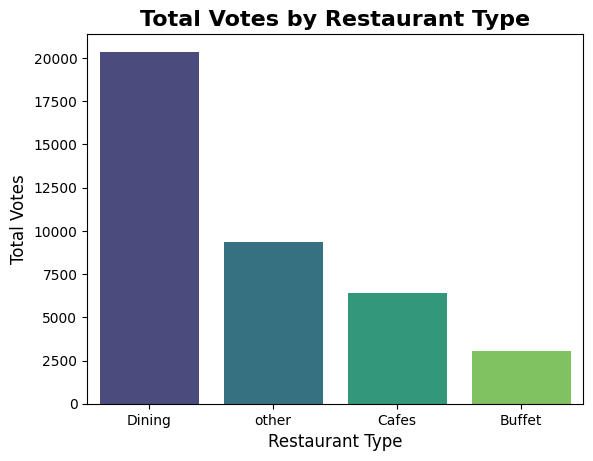

In [33]:
sns.barplot(x="Resturant_Type", y="Total_Votes", data=vote, palette="viridis")
plt.title("Total Votes by Restaurant Type", fontsize=16, fontweight="bold")
plt.xlabel("Restaurant Type", fontsize=12)
plt.ylabel("Total Votes", fontsize=12)

Answer 3: Top 5 Ratings received by majority of restaurants:


Rating,Restaurant Count
3.8/5,19
3.7/5,15
3.3/5,14
3.4/5,12
3.6/5,11


([<matplotlib.patches.Wedge at 0x7846462e3b90>,
 [Text(0.7336290798830107, 0.8196269719512694, '3.8/5'),
  Text(-0.7691660940651315, 0.7863736514791104, '3.7/5'),
  Text(-0.9722559059579271, -0.5145079720761676, '3.3/5'),
  Text(0.07295553072011395, -1.0975780111396851, '3.4/5'),
  Text(0.9722562862333327, -0.5145072534763413, '3.6/5')])

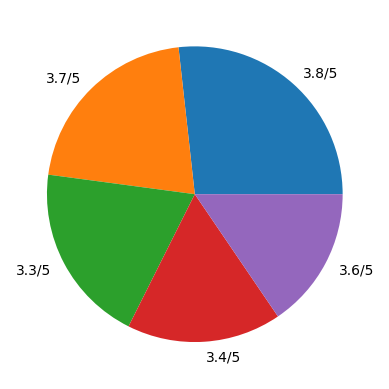

In [34]:
# What are the ratings that the majority of restaurants have received?
ratings_count = df['rate'].value_counts().reset_index()
ratings_count.columns = ['Rating', 'Restaurant Count']
print("Answer 3: Top 5 Ratings received by majority of restaurants:")
display(ratings_count.head(5).style.hide(axis='index'))
plt.pie(data=ratings_count.head(),x="Restaurant Count",labels="Rating")

In [35]:
# Zomato has observed that most couples order most of their food online. What is their average spending on each order?
avg_spend=df[df["online_order"]=="Yes"]
avg_order=avg_spend["approx_cost(for two people)"].mean()
print("Average spending on online orders:")
print(avg_order.round(2))

Average spending on online orders:
510.34


In [36]:
# Which mode (online or offline) has received the maximum rating?
max_rating_mode = df.groupby('online_order')['rate'].max().reset_index()
max_rating_mode.column=['Online Order (Mode)', 'Maximum Rating']
print("Answer 5: Maximum rating received by each mode:")
display(max_rating_mode.style.hide(axis='index'))



Answer 5: Maximum rating received by each mode:


/tmp/ipykernel_22526/348169538.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  max_rating_mode.column=['Online Order (Mode)', 'Maximum Rating']


online_order,rate
No,4.3/5
Yes,4.6/5


In [37]:
# Which type of restaurant received more offline orders, so that Zomato can provide those customers with some good offers?
offline_order = df[df["online_order"] == "No"]
restro = offline_order["listed_in(type)"].value_counts().reset_index()
restro.columns = ['Restaurant Type', 'Offline Orders Count']
print("Answer 6: Restaurant types with most offline orders:")
display(restro.style.hide(axis='index'))

Answer 6: Restaurant types with most offline orders:


Restaurant Type,Offline Orders Count
Dining,77
Cafes,8
Buffet,3
other,2
